In [14]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# 1. Ajuste Dinámico de Rutas
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

# 2. Importación, Recarga y Ejecución
try:
    # Importamos los módulos
    import extract
    import transform
    import load
    import audit
    import visualize

    # Forzamos la recarga para reconocer cambios en los archivos .py
    importlib.reload(audit)
    importlib.reload(transform)
    importlib.reload(extract)
    importlib.reload(load)
    importlib.reload(visualize)

    # Vinculamos las funciones
    from extract import ejecutar_extraccion
    from transform import transformar_datos  
    from load import cargar_datos
    from audit import ejecutar_auditoria
    from visualize import generar_reporte_visual

    # --- EJECUCIÓN ---
    # Primero transformamos
    df_final = transformar_datos(datasets)
    
    # Luego auditamos (Esta línea debe estar indentada aquí adentro)
    ejecutar_auditoria(df_final, datasets, "data/processed/olist_final.db")
    
    print("Sincronización y Auditoría exitosa.")

except ImportError as e:
    print(f" Error Crítico de Importación: {e}")
except Exception as e:
    print(f" Error durante la ejecución: {e}")

--- Iniciando Fase de Transformación ---
Traduciendo muestra de feedback crítico...
Transformación completada: 113314 registros.

📊 REPORTE DE KPIs DE INGENIERÍA (ETL)
1. Tasa de Vinculación: 99.22%
2. Completitud de Reseñas (NLP): 42.04%
3. Consistencia SQL: EXITOSA
   (Filas: 113314)

Sincronización y Auditoría exitosa.


In [15]:
# %% [PASO 1] EXTRACCIÓN GLOBAL
# Llamamos a la función (que solo devuelve el diccionario)
datasets = ejecutar_extraccion()

# Verificamos si el diccionario no está vacío (eso sería nuestro "éxito")
if datasets:
    print(f"Estado: {len(datasets)} archivos cargados exitosamente.")
    # Mostramos una lista de lo que tenemos en memoria
    for tabla, df in datasets.items():
        print(f"-> {tabla}: {df.shape[0]} registros.")
else:
    print("Error: No se pudo cargar ningún dataset. Verifica las rutas.")

Iniciando Extracción...
Estado: 6 archivos cargados exitosamente.
-> orders: 99441 registros.
-> items: 112650 registros.
-> products: 32951 registros.
-> reviews: 99224 registros.
-> customers: 99441 registros.
-> category_translation: 71 registros.


In [16]:
# %% [PASO 2] PROCESAMIENTO DE DATOS (MERGE)
# Usamos 'transformar_datos' que es el nombre que definimos en src/transform.py
df_final = transformar_datos(datasets)

print(f"Procesamiento completado: {df_final.shape[0]} filas generadas.")

--- Iniciando Fase de Transformación ---
Traduciendo muestra de feedback crítico...
Transformación completada: 113314 registros.
Procesamiento completado: 113314 filas generadas.


In [17]:
# %% [PASO 2.1] VERIFICACIÓN DE DATOS PROCESADOS
# En lugar de hacer merge manual, verificamos lo que la función ya hizo:

print("Columnas actuales en el DataFrame final:")
print(df_final.columns.tolist())

# Verificamos si tenemos la traducción al inglés 
if 'product_category_name_english' in df_final.columns:
    print("\nÉxito: La columna de categoría en inglés está presente.")
    print(df_final[['product_category_name_english']].head(5))
else:
    print("\nAtención: No se encontró la traducción. Revisa la lógica en transform.py")

# Verificamos una muestra de la traducción de reseñas (NLP)
if 'review_espanol' in df_final.columns:
    quejas_traducidas = df_final[df_final['review_espanol'] != ""]
    print(f"\nReseñas traducidas: {len(quejas_traducidas)}")

Columnas actuales en el DataFrame final:
['order_id', 'customer_id', 'customer_city', 'customer_state', 'product_category_name_english', 'price_usd', 'review_score', 'sentiment_es', 'review_comment_message', 'review_espanol', 'delivery_delta_days', 'order_purchase_timestamp']

Éxito: La columna de categoría en inglés está presente.
  product_category_name_english
0                    housewares
1                     perfumery
2                          auto
3                      pet_shop
4                    stationery

Reseñas traducidas: 15


In [19]:
# %% [PASO 2.2] TRANSFORMACIÓN: FORMATEO DE FECHAS SEGURO
columnas_fecha_objetivo = [
    "order_purchase_timestamp", 
    "order_delivered_customer_date", 
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

# Identificamos cuáles de esas columnas están realmente presentes en df_final
columnas_presentes = [col for col in columnas_fecha_objetivo if col in df_final.columns]

if columnas_presentes:
    # Convertimos solo las que existen
    for col in columnas_presentes:
        df_final[col] = pd.to_datetime(df_final[col], errors='coerce')
    
    print("Conversión de fechas finalizada para las columnas encontradas.")
    # Mostramos solo las que pudimos procesar
    print(df_final[columnas_presentes].dtypes)
else:
    print("Aviso: No se encontraron columnas de fecha en df_final.")
    print("Columnas disponibles actualmente:", df_final.columns.tolist())

Conversión de fechas finalizada para las columnas encontradas.
order_purchase_timestamp    datetime64[us]
dtype: object


In [20]:
    # %% [INSPECCIÓN] LISTAR COLUMNAS DISPONIBLES
    print("Columnas encontradas en df_final:")
    print(df_final.columns.tolist())

    # Verificamos si la columna de categorías existe o tiene otro nombre
    col_categoria = 'product_category_name_english' if 'product_category_name_english' in df_final.columns else 'product_category_name'
    print(f"\nUsando la columna: {col_categoria}")

Columnas encontradas en df_final:
['order_id', 'customer_id', 'customer_city', 'customer_state', 'product_category_name_english', 'price_usd', 'review_score', 'sentiment_es', 'review_comment_message', 'review_espanol', 'delivery_delta_days', 'order_purchase_timestamp']

Usando la columna: product_category_name_english


In [21]:
# %% [PASO 3.1] PROCESO: CONVERSIÓN MONETARIA 
print("Transformacion: Estandarizacion de precios a USD")

# Solo seleccionamos las columnas que realmente existen en df_final
# Quitamos 'price' porque ya fue transformado a 'price_usd'
cols_disponibles = ['order_id', 'price_usd'] 

if 'price_usd' in df_final.columns:
    display(df_final[cols_disponibles].sample(10))

    # Estadisticos basicos para la exposicion
    media_usd = df_final['price_usd'].mean()
    print(f"\nEl ticket promedio de venta es de: ${media_usd:.2f} USD")
else:
    print("Error: La columna 'price_usd' no se encontró. Verifica la transformación.")

Transformacion: Estandarizacion de precios a USD


,order_id,price_usd
112932,4fed711323f674330ff12f1834049b3a,20.510256
69232,95cf53396116b5dd518b5ba1c11a0bb5,15.128205
72009,c6981eae927738695c85c3528192c98b,12.794872
101262,777d466afbadf685826ca5de0e152684,4.443590
36229,ee46e60afd0a0052089f6729df72feec,11.769231
112518,83c76350df165cbfe7c4f88eb43c2f00,7.564103
104896,9fec37a0086c6f77f95b2ac00f27771e,47.410256
33221,17f1e34933ddc8813aac392cf52fc5ba,28.179487
34231,85a00341850d3ac099340d190e2ec046,43.051282
17732,f57ef42b585d020c6a058a8334fae1e6,43.846154



El ticket promedio de venta es de: $30.89 USD


In [22]:
# %% [PASO 3.2] PROCESO: LIMPIEZA DE CIUDADES
print("Transformacion: Normalizacion de Nombres de Ciudades")

# Listamos las ciudades unicas para demostrar la limpieza
ciudades_limpias = df_final['customer_city'].unique()
print(f"Total ciudades procesadas: {len(ciudades_limpias)}")
print("\nMuestra de resultados (Sin caracteres especiales):")
print(ciudades_limpias[:15])

Transformacion: Normalizacion de Nombres de Ciudades
Total ciudades procesadas: 4110

Muestra de resultados (Sin caracteres especiales):
<StringArray>
[              'SAO PAULO',               'BARREIRAS',
              'VIANOPOLIS', 'SAO GONCALO DO AMARANTE',
             'SANTO ANDRE',            'CONGONHINHAS',
              'SANTA ROSA',               'NILOPOLIS',
            'FAXINALZINHO',                'SOROCABA',
          'RIO DE JANEIRO',              'OURO PRETO',
                 'GOIANIA',                'IMBITUBA',
             'HORTOLANDIA']
Length: 15, dtype: str


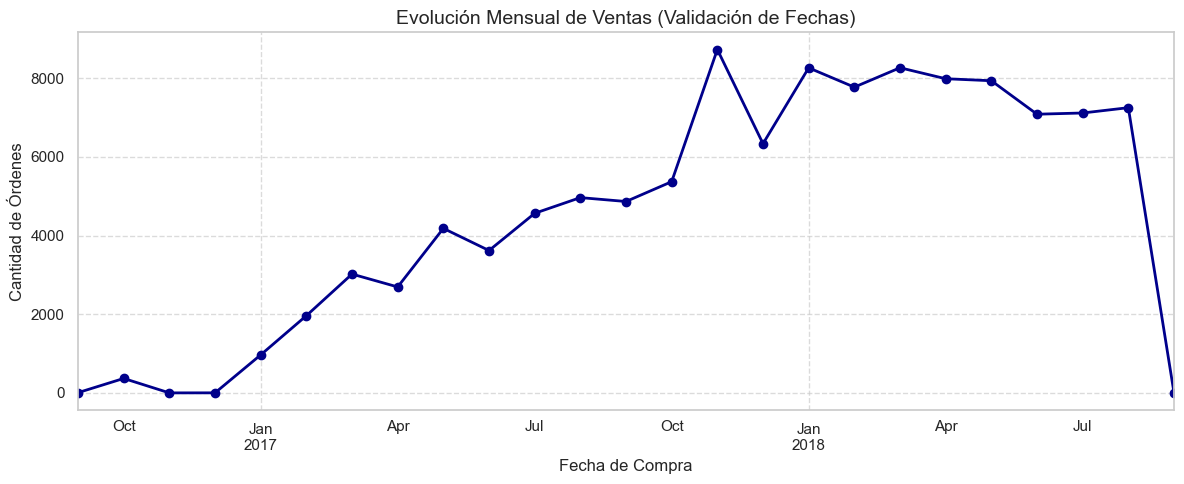

In [23]:
# %% [PASO 3.3] PROCESO: ANÁLISIS TEMPORAL
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Cambiamos 'M' por 'ME' (Month End) para evitar el ValueError
# También filtramos nulos por si alguna fecha no se convirtió correctamente
df_temp = df_final.dropna(subset=['order_purchase_timestamp'])

ventas_mensuales = df_temp.set_index('order_purchase_timestamp').resample('ME')['order_id'].count()

# Dibujamos el gráfico
ventas_mensuales.plot(kind='line', marker='o', color='darkblue', linewidth=2)

plt.title('Evolución Mensual de Ventas (Validación de Fechas)', fontsize=14)
plt.xlabel('Fecha de Compra')
plt.ylabel('Cantidad de Órdenes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

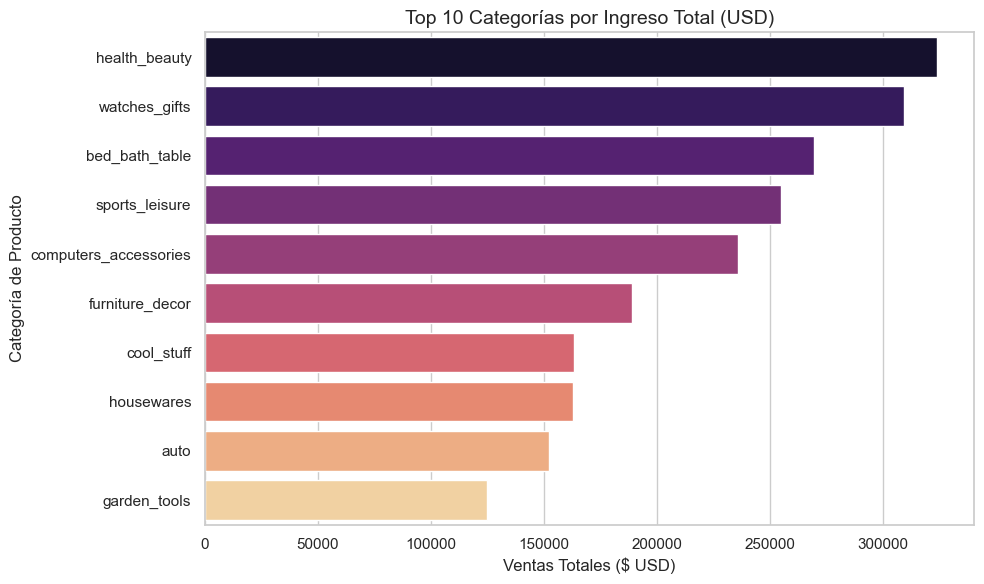

In [24]:
# %% [PASO 3.4] ANALISIS DE CATEGORIAS (VALOR ECONOMICO)
plt.figure(figsize=(10, 6))

# Validación dinámica de la columna de categoría
# Priorizamos la traducción al inglés si existe, si no, usamos la original
col_cat = 'product_category_name_english' if 'product_category_name_english' in df_final.columns else 'product_category_name'

if col_cat in df_final.columns and 'price_usd' in df_final.columns:
    # Agrupación por ingresos totales en USD
    ingresos_cat = df_final.groupby(col_cat)['price_usd'].sum().sort_values(ascending=False).head(10)

    # Generación del gráfico de barras
    sns.barplot(
        x=ingresos_cat.values, 
        y=ingresos_cat.index, 
        hue=ingresos_cat.index, 
        palette='magma', 
        legend=False
    )

    plt.title(f'Top 10 Categorías por Ingreso Total (USD)', fontsize=14)
    plt.xlabel('Ventas Totales ($ USD)')
    plt.ylabel('Categoría de Producto')
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: No se encontró la columna '{col_cat}' o 'price_usd' para graficar.")

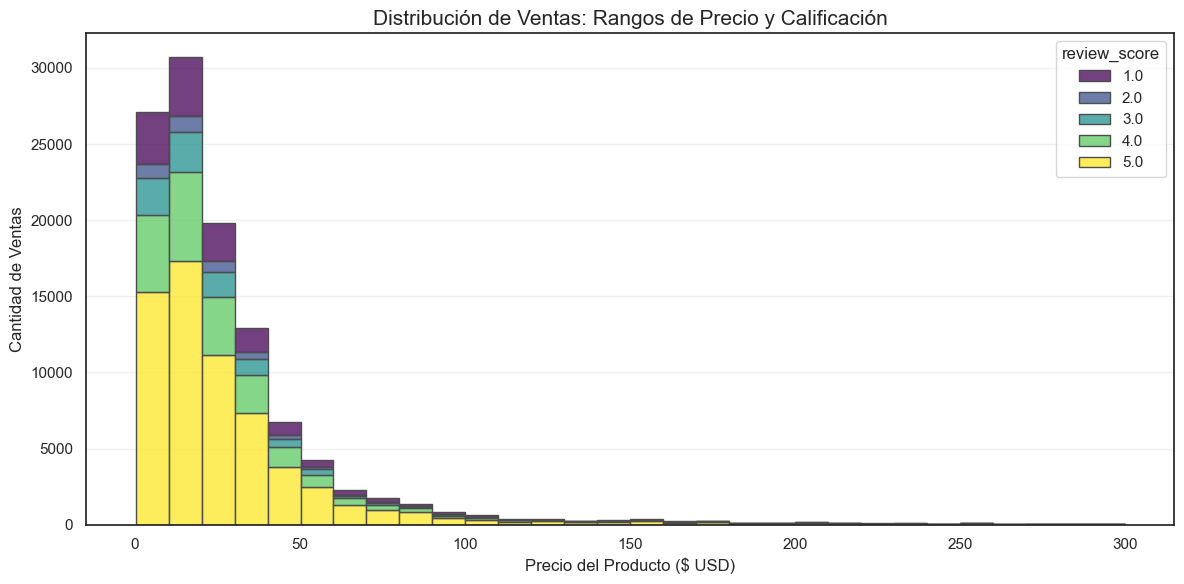

In [25]:
# %% [PASO 3.5] HISTOGRAMA SENCILLO: DISTRIBUCIÓN DE PRECIOS POR SCORE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración estética
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))

# 2. Filtramos datos para que el gráfico no se vea "aplastado" por precios extremos
# Filtramos productos de hasta $300 USD (ajusta según tu dataset)
df_hist = df_final[df_final['price_usd'] < 300].dropna(subset=['review_score'])

# 3. Creamos el histograma apilado
sns.histplot(
    data=df_hist,
    x='price_usd',
    hue='review_score',
    multiple="stack",    # Apila los scores uno sobre otro
    palette="viridis",   # Escala de colores clara
    bins=30,             # Número de barras
    edgecolor=".3"
)

plt.title('Distribución de Ventas: Rangos de Precio y Calificación', fontsize=15)
plt.xlabel('Precio del Producto ($ USD)', fontsize=12)
plt.ylabel('Cantidad de Ventas', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# %% [PASO 3.6] TRANSFORMACIÓN: TABLA MAESTRA DE RESEÑAS
import pandas as pd

# 1. Unimos Reviews con Orders (para tener las fechas y el estado)
df_reviews_complete = pd.merge(
    datasets['reviews'], 
    datasets['orders'], 
    on='order_id', 
    how='inner'
)

# 2. Unimos con Items y Products (para saber qué producto recibió la reseña)
# Nota: Una orden puede tener varios productos, aquí se asocia la reseña a cada uno
df_reviews_complete = df_reviews_complete.merge(
    datasets['items'][['order_id', 'product_id', 'price']], 
    on='order_id', 
    how='left'
).merge(
    datasets['products'][['product_id', 'product_category_name']], 
    on='product_id', 
    how='left'
).merge(
    datasets['category_translation'], 
    on='product_category_name', 
    how='left'
)

# 3. Limpieza de textos en las reseñas 
df_reviews_complete['review_comment_message'] = df_reviews_complete['review_comment_message'].fillna("Sin comentario")
df_reviews_complete['review_comment_title'] = df_reviews_complete['review_comment_title'].fillna("Sin título")

print(f"Tabla de reseñas cruzada creada con {len(df_reviews_complete)} registros.")

Tabla de reseñas cruzada creada con 113131 registros.


In [27]:
# %% [PASO 3.7] ANÁLISIS: TOP CATEGORÍAS POR SATISFACCIÓN
# Agrupamos por categoría en inglés y calculamos el promedio de score y cantidad de reseñas
tabla_score_categoria = df_reviews_complete.groupby('product_category_name_english').agg(
    promedio_score=('review_score', 'mean'),
    total_resenas=('review_id', 'count'),
    precio_promedio=('price', 'mean')
).reset_index()

# Filtramos categorías con más de 100 reseñas para que el promedio sea confiable
tabla_score_categoria = tabla_score_categoria[tabla_score_categoria['total_resenas'] > 100]

# Ordenamos por las mejores calificadas
top_satisfaccion = tabla_score_categoria.sort_values(by='promedio_score', ascending=False).head(10)

print("Top 10 Categorías con Clientes más Satisfechos:")
display(top_satisfaccion)

Top 10 Categorías con Clientes más Satisfechos:


,product_category_name_english,promedio_score,total_resenas,precio_promedio
8,books_general_interest,4.446266,549,84.845410
10,books_technical,4.368421,266,71.579286
37,food_drink,4.315412,279,54.643262
53,luggage_accessories,4.315257,1088,128.534191
31,fashion_shoes,4.233716,261,89.532835
36,food,4.218182,495,58.455374
66,stationery,4.193857,2507,91.677615
60,pet_shop,4.185147,1939,110.120124
14,computers,4.175000,200,1070.990650
44,home_appliances,4.172457,806,102.945099


In [28]:
# %% [PASO 3.8] TRANSFORMACIÓN: ENRIQUECIMIENTO LINGÜÍSTICO
try:
    from deep_translator import GoogleTranslator
    USAR_TRADUCTOR = True
except ImportError:
    USAR_TRADUCTOR = False

print("--- Iniciando validación de columnas de reseñas ---")

# 1. VERIFICACIÓN: Si no está el mensaje, lo traemos de vuelta
if 'review_comment_message' not in df_final.columns:
    print("Columna 'review_comment_message' no encontrada. Recuperando de datasets['reviews']...")
    # Hacemos un merge por 'order_id' para recuperar los comentarios
    df_final = pd.merge(
        df_final, 
        datasets['reviews'][['order_id', 'review_comment_message']], 
        on='order_id', 
        how='left'
    )

# 2. Categorización de Sentimiento (Siempre funciona)
def transformar_sentimiento(score):
    if score >= 4: return 'Satisfecho (Positivo)'
    elif score == 3: return 'Neutral'
    else: return 'Crítico (Negativo)'

df_final['sentiment_es'] = df_final['review_score'].apply(transformar_sentimiento)

# 3. Traducción de muestra de quejas (Solo si hay traductor e internet)
if USAR_TRADUCTOR:
    # Aseguramos que no haya nulos para el filtro
    df_final['review_comment_message'] = df_final['review_comment_message'].fillna("")
    
    mask_criticas = (df_final['review_score'] <= 2) & (df_final['review_comment_message'].str.len() > 5)
    df_criticas_traducidas = df_final[mask_criticas].head(8).copy()

    if not df_criticas_traducidas.empty:
        try:
            translator = GoogleTranslator(source='pt', target='es')
            print("Traduciendo quejas reales al español...")
            
            df_criticas_traducidas['review_espanol'] = df_criticas_traducidas['review_comment_message'].apply(
                lambda x: translator.translate(x)
            )
            
            print("\nAnálisis de Sentimiento y Traducción (Muestra):")
            display(df_criticas_traducidas[['order_id', 'sentiment_es', 'review_comment_message', 'review_espanol']])
        except Exception as e:
            print(f"Nota: Falló la conexión con el traductor: {e}")
    else:
        print("No se encontraron comentarios largos para traducir en la muestra crítica.")
else:
    print("Modo sin traducción: Sentiment analysis completado.")

--- Iniciando validación de columnas de reseñas ---
Traduciendo quejas reales al español...

Análisis de Sentimiento y Traducción (Muestra):


,order_id,sentiment_es,review_comment_message,review_espanol
6,136cce7faa42fdb2cefd53fdc79a6098,Crítico (Negativo),fiquei triste por n ter me atendido.,Me entristeció que no me respondieras.
10,e6ce16cb79ec1d90b1da9085a6118aeb,Crítico (Negativo),Aguardando retorno da loja,Esperando devolución de la tienda.
11,e6ce16cb79ec1d90b1da9085a6118aeb,Crítico (Negativo),Aguardando retorno da loja,Esperando devolución de la tienda.
21,203096f03d82e0dffbc41ebc2e2bcfb7,Crítico (Negativo),os correios estäo em greve... näo recebi nenhu...,el correo está en huelga... No recibí ningún a...
26,fbf9ac61453ac646ce8ad9783d7d0af6,Crítico (Negativo),Demora muito entregar. Já passou o prazo e ain...,Tarda mucho en entregar. Ya pasó el plazo y to...
27,acce194856392f074dbf9dada14d8d82,Crítico (Negativo),Até o momento não recebi o produto Protetor De...,Hasta el momento no he recibido el producto Pr...
28,acce194856392f074dbf9dada14d8d82,Crítico (Negativo),Até o momento não recebi o produto Protetor De...,Hasta el momento no he recibido el producto Pr...
32,f70a0aff17df5a6cdd9a7196128bd354,Crítico (Negativo),O produto veio faltando a base para auto e com...,Al producto le faltaba la base del automóvil y...


In [29]:
# %% [PASO 3.9] ANÁLISIS FINAL: CATEGORÍAS CON MAYOR SENTIMIENTO NEGATIVO
print("--- Generando Reporte de Calidad por Categoría ---")

# 1. Creamos la tabla cruzada (Categoría vs Sentimiento)
reporte_sentimiento = pd.crosstab(
    df_final['product_category_name_english'], 
    df_final['sentiment_es'], 
    normalize='index'
) * 100

# 2. Filtramos categorías con volumen representativo (> 50 ventas)
conteo_categorias = df_final['product_category_name_english'].value_counts()
categorias_relevantes = conteo_categorias[conteo_categorias > 50].index
reporte_filtrado = reporte_sentimiento.loc[categorias_relevantes]

# 3. Ordenamos por las que tienen mayor % de 'Crítico (Negativo)'
top_riesgo = reporte_filtrado.sort_values(by='Crítico (Negativo)', ascending=False).head(10)

print("\nTOP 10 CATEGORÍAS CON MAYOR ÍNDICE DE INSATISFACCIÓN:")
# NOTA: Usamos .map() en lugar de .applymap() para compatibilidad con Pandas 2.x
display(top_riesgo.round(2).map(lambda x: f"{x}%"))

# 4. Resumen estadístico final
total_negativas = (df_final['sentiment_es'] == 'Crítico (Negativo)').sum()
porcentaje_global = (total_negativas / len(df_final)) * 100
print(f"\nNota: El {porcentaje_global:.2f}% de todas las órdenes analizadas son críticas.")

--- Generando Reporte de Calidad por Categoría ---

TOP 10 CATEGORÍAS CON MAYOR ÍNDICE DE INSATISFACCIÓN:


sentiment_es,Crítico (Negativo),Neutral,Satisfecho (Positivo)
product_category_name_english,,,
fashion_male_clothing,28.79%,5.3%,65.91%
office_furniture,26.69%,14.11%,59.2%
fixed_telephony,26.42%,7.17%,66.42%
audio,22.74%,9.59%,67.67%
construction_tools_safety,20.62%,8.76%,70.62%
home_confort,20.59%,12.81%,66.59%
furniture_decor,20.26%,8.96%,70.78%
bed_bath_table,19.92%,9.84%,70.24%
air_conditioning,19.19%,8.08%,72.73%



Nota: El 16.81% de todas las órdenes analizadas son críticas.


In [30]:
# %% [PASO 4] CARGA (LOAD) A SQLITE
import sqlite3
import os

# 1. Definimos la ruta y el nombre de la base de datos
ruta_db = "data/processed/olist_final.db"
nombre_tabla = "reporte_ventas"

# Nos aseguramos de que la carpeta exista
os.makedirs("data/processed", exist_ok=True)

print(f"Iniciando carga de {len(df_final)} registros en la base de datos...")

try:
    # 2. Creamos la conexión y guardamos el DataFrame
    with sqlite3.connect(ruta_db) as conn:
        # 'replace' asegura que si corres el código de nuevo, la tabla se actualice
        df_final.to_sql(nombre_tabla, conn, if_exists='replace', index=False)
    
    print(f"¡ÉXITO! Datos persistidos en: {ruta_db}")
    
    # 3. Verificación rápida para demostrar integridad ante el profesor
    conn = sqlite3.connect(ruta_db)
    query_verificacion = f"SELECT COUNT(*) as total FROM {nombre_tabla}"
    resultado = pd.read_sql(query_verificacion, conn)
    print(f"Confirmación SQL: La tabla '{nombre_tabla}' tiene {resultado['total'][0]} filas cargadas.")
    conn.close()

except Exception as e:
    print(f"Error durante la carga: {e}")

Iniciando carga de 113314 registros en la base de datos...
¡ÉXITO! Datos persistidos en: data/processed/olist_final.db
Confirmación SQL: La tabla 'reporte_ventas' tiene 113314 filas cargadas.


In [31]:
# %% [PASO 5] AUDITORÍA TÉCNICA Y KPIs (Sustentación)
from audit import ejecutar_auditoria

print("Generando métricas de calidad para el anteproyecto...")

# Definimos las rutas que usamos en el Notebook
ruta_db_notebook = "data/processed/olist_final.db"

# Ejecutamos la función de auditoría que creamos en src/audit.py
ejecutar_auditoria(df_final, datasets, ruta_db_notebook)

print("Métricas listas para la presentación del Seminario.")

Generando métricas de calidad para el anteproyecto...

📊 REPORTE DE KPIs DE INGENIERÍA (ETL)
1. Tasa de Vinculación: 99.22%
2. Completitud de Reseñas (NLP): 42.04%
3. Consistencia SQL: EXITOSA
   (Filas: 113314)

Métricas listas para la presentación del Seminario.
